# 原始宏观数据去噪后 Bry-Boschan 拐点整理

读取 `output_宏观_pkl/M0000612.pkl` 和 `output_宏观_pkl/M0017126.pkl`，先对原始月度序列做一层稳健去噪，再对去噪后的序列应用 Bry-Boschan-like 拐点识别。

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
PKL_DIR = ROOT / "output_宏观_pkl"
OUT = ROOT / "raw_macro_bry_boschan_nonoise_output"
OUT.mkdir(exist_ok=True)

# 这两个 pkl 都是从 2026-05-31 开始向前走的月度数据；如果 pkl 自带日期索引，会优先使用索引。
START_DATE = pd.Timestamp("2026-05-31")

SERIES = {
    "inflation": {"code": "M0000612", "name": "中国:CPI:当月同比"},
    "growth": {"code": "M0017126", "name": "中国:制造业PMI"},
}

# BB 参数沿用 check_data.ipynb。
BB_WINDOW = 5
MIN_PHASE = 5
MIN_CYCLE = 15

# 去噪参数：先用滚动中位数识别尖刺，再用 3 月居中均值做轻度平滑。
OUTLIER_WINDOW = 5
OUTLIER_MAD_K = 3.0
SMOOTH_WINDOW = 3

## 1. 读取并整理原始月度序列

In [3]:
def _first_numeric_series(obj) -> pd.Series:
    """从 pickle 读出的 Series/DataFrame 中取出第一列可转成数值的序列。"""
    if isinstance(obj, pd.Series):
        return pd.to_numeric(obj, errors="coerce")

    if isinstance(obj, pd.DataFrame):
        numeric = obj.apply(pd.to_numeric, errors="coerce")
        non_empty_cols = [col for col in numeric.columns if numeric[col].notna().any()]
        if not non_empty_cols:
            raise ValueError("DataFrame 中没有可转成数值的列")
        return numeric[non_empty_cols[0]]

    return pd.to_numeric(pd.Series(obj), errors="coerce")


def read_monthly_pkl(code: str, start_date: pd.Timestamp = START_DATE) -> pd.Series:
    path = PKL_DIR / f"{code}.pkl"
    if not path.exists():
        raise FileNotFoundError(path)

    raw = _first_numeric_series(pd.read_pickle(path)).dropna()
    idx_text = pd.Series(raw.index.astype(str)).str.strip()
    parsed_idx = pd.to_datetime(idx_text, errors="coerce")

    if parsed_idx.notna().any():
        s = pd.Series(raw.to_numpy(), index=parsed_idx)
        s = s[s.index.notna()]
    else:
        dates = [start_date - pd.offsets.MonthEnd(i) for i in range(len(raw))]
        s = pd.Series(raw.to_numpy(), index=pd.DatetimeIndex(dates))

    month_end = pd.DatetimeIndex(s.index).to_period("M").to_timestamp("M")
    monthly = pd.Series(s.to_numpy(), index=month_end).sort_index().groupby(level=0).last()
    regular = monthly.reindex(pd.date_range(monthly.index.min(), monthly.index.max(), freq="ME"))
    return regular.interpolate(limit=2).dropna()


raw_series = {factor: read_monthly_pkl(info["code"]) for factor, info in SERIES.items()}

raw_data = pd.concat(
    {SERIES[factor]["code"]: series for factor, series in raw_series.items()},
    axis=1,
).rename_axis("date")
raw_data.columns = [SERIES["inflation"]["name"], SERIES["growth"]["name"]]

data_overview = pd.DataFrame([
    {
        "factor": factor,
        "code": SERIES[factor]["code"],
        "name": SERIES[factor]["name"],
        "start": series.index.min(),
        "end": series.index.max(),
        "nobs": len(series),
        "last_value": series.iloc[-1],
    }
    for factor, series in raw_series.items()
])

display(data_overview)
display(raw_data.tail(12))

C:\Users\16492\AppData\Local\Temp\ipykernel_30016\4243731994.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_idx = pd.to_datetime(idx_text, errors="coerce")
C:\Users\16492\AppData\Local\Temp\ipykernel_30016\4243731994.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_idx = pd.to_datetime(idx_text, errors="coerce")


,factor,code,name,start,end,nobs,last_value
0,inflation,M0000612,中国:CPI:当月同比,1987-01-31,2026-05-31,473,1.2
1,growth,M0017126,中国:制造业PMI,2005-01-31,2026-05-31,257,50.0


,中国:CPI:当月同比,中国:制造业PMI
date,,
2025-06-30,0.1,49.7
2025-07-31,0.0,49.3
2025-08-31,-0.4,49.4
2025-09-30,-0.3,49.8
2025-10-31,0.2,49.0
2025-11-30,0.7,49.2
2025-12-31,0.8,50.1
2026-01-31,0.2,49.3
2026-02-28,1.3,49.0


## 2. 稳健去噪

这里使用两步法：

1. 用 5 月滚动中位数和 MAD 识别局部尖刺，把尖刺替换成局部中位数。
2. 对替换后的序列做 3 月居中滚动均值，降低月度噪声。

In [4]:
def robust_denoise(
    y: pd.Series,
    outlier_window: int = OUTLIER_WINDOW,
    mad_k: float = OUTLIER_MAD_K,
    smooth_window: int = SMOOTH_WINDOW,
) -> pd.Series:
    y = y.astype(float).dropna().sort_index()

    rolling_median = y.rolling(outlier_window, center=True, min_periods=1).median()
    abs_dev = (y - rolling_median).abs()
    rolling_mad = abs_dev.rolling(outlier_window, center=True, min_periods=1).median()

    # MAD 为 0 时说明局部非常平稳；替换成一个很小的数，避免除零。
    scale = (1.4826 * rolling_mad).replace(0, np.nan)
    robust_z = abs_dev / scale
    outlier_mask = robust_z > mad_k

    cleaned = y.mask(outlier_mask, rolling_median)
    denoised = cleaned.rolling(smooth_window, center=True, min_periods=1).mean()
    denoised.name = y.name
    return denoised


denoised_series = {factor: robust_denoise(series) for factor, series in raw_series.items()}

compare_data = pd.concat(
    {
        "inflation_raw": raw_series["inflation"],
        "inflation_denoised": denoised_series["inflation"],
        "growth_raw": raw_series["growth"],
        "growth_denoised": denoised_series["growth"],
    },
    axis=1,
).rename_axis("date")

display(compare_data.tail(12))

,inflation_raw,inflation_denoised,growth_raw,growth_denoised
date,,,,
2025-06-30,0.1,2.312965e-15,49.7,49.500000
2025-07-31,0.0,-1.000000e-01,49.3,49.466667
2025-08-31,-0.4,-2.333333e-01,49.4,49.500000
2025-09-30,-0.3,-1.666667e-01,49.8,49.400000
2025-10-31,0.2,2.000000e-01,49.0,49.333333
2025-11-30,0.7,5.666667e-01,49.2,49.433333
2025-12-31,0.8,5.666667e-01,50.1,49.533333
2026-01-31,0.2,7.666667e-01,49.3,49.466667
2026-02-28,1.3,8.333333e-01,49.0,49.566667


## 3. Bry-Boschan-like 拐点函数

In [6]:
def local_turns(y: pd.Series, window: int = 5) -> pd.DataFrame:
    y = y.dropna()
    rows = []
    for i in range(window, len(y) - window):
        block = y.iloc[i - window : i + window + 1]
        value = y.iloc[i]
        if value == block.max() and value > y.iloc[i - 1] and value > y.iloc[i + 1]:
            rows.append({"date": y.index[i], "type": "peak", "value": value})
        if value == block.min() and value < y.iloc[i - 1] and value < y.iloc[i + 1]:
            rows.append({"date": y.index[i], "type": "trough", "value": value})
    return pd.DataFrame(rows, columns=["date", "type", "value"]).sort_values("date").reset_index(drop=True)


def alternate(turns: pd.DataFrame) -> pd.DataFrame:
    if turns.empty:
        return turns.copy()
    kept = []
    for row in turns.to_dict("records"):
        if not kept or row["type"] != kept[-1]["type"]:
            kept.append(row)
            continue
        better_peak = row["type"] == "peak" and row["value"] > kept[-1]["value"]
        better_trough = row["type"] == "trough" and row["value"] < kept[-1]["value"]
        if better_peak or better_trough:
            kept[-1] = row
    return pd.DataFrame(kept, columns=turns.columns)


def enforce_lengths(turns: pd.DataFrame, min_phase: int = 5, min_cycle: int = 15) -> pd.DataFrame:
    turns = alternate(turns)
    changed = True
    while changed and len(turns) > 2:
        changed = False
        turns = turns.reset_index(drop=True)

        for i in range(len(turns) - 1):
            months = (turns.loc[i + 1, "date"].to_period("M") - turns.loc[i, "date"].to_period("M")).n
            if months < min_phase:
                amp_left = abs(turns.loc[i, "value"] - turns["value"].median())
                amp_right = abs(turns.loc[i + 1, "value"] - turns["value"].median())
                turns = turns.drop(i if amp_left < amp_right else i + 1)
                changed = True
                break
        if changed:
            turns = alternate(turns)
            continue

        for i in range(len(turns) - 2):
            months = (turns.loc[i + 2, "date"].to_period("M") - turns.loc[i, "date"].to_period("M")).n
            if turns.loc[i, "type"] == turns.loc[i + 2, "type"] and months < min_cycle:
                if turns.loc[i, "type"] == "peak":
                    drop_i = i if turns.loc[i, "value"] < turns.loc[i + 2, "value"] else i + 2
                else:
                    drop_i = i if turns.loc[i, "value"] > turns.loc[i + 2, "value"] else i + 2
                turns = turns.drop(drop_i)
                changed = True
                break
        turns = alternate(turns)
    return turns.reset_index(drop=True)


def bry_boschan_like(y: pd.Series, window: int = BB_WINDOW, min_phase: int = MIN_PHASE, min_cycle: int = MIN_CYCLE) -> pd.DataFrame:
    turns = enforce_lengths(local_turns(y, window=window), min_phase=min_phase, min_cycle=min_cycle)
    if turns.empty:
        turns["turn"] = []
        return turns
    turns["turn"] = turns["type"].map({"peak": "高点", "trough": "低点"})
    return turns


def phase_by_turns(index: pd.DatetimeIndex, turns: pd.DataFrame) -> pd.Series:
    phase = pd.Series(index=index, dtype="object")
    if turns.empty or len(index) == 0:
        return phase
    turns = turns.sort_values("date").reset_index(drop=True)

    first = turns.loc[0]
    before_first = "上行" if first["type"] == "peak" else "下行"
    phase.loc[index < first["date"]] = before_first

    for i, row in turns.iterrows():
        start = row["date"]
        end = turns.loc[i + 1, "date"] if i < len(turns) - 1 else index[-1] + pd.offsets.MonthEnd(1)
        after_turn = "下行" if row["type"] == "peak" else "上行"
        phase.loc[(index >= start) & (index < end)] = after_turn
    return phase

## 4. 对去噪后的 CPI/PMI 跑 BB

In [7]:
turn_rows = []
for factor, series in denoised_series.items():
    turns = bry_boschan_like(series)
    turns.insert(0, "filter", "robust_median_then_3m_ma")
    turns.insert(1, "factor", factor)
    turns.insert(2, "code", SERIES[factor]["code"])
    turns.insert(3, "name", SERIES[factor]["name"])
    turn_rows.append(turns)

denoised_turning_points = pd.concat(turn_rows, ignore_index=True)

common_index = denoised_series["growth"].index.intersection(denoised_series["inflation"].index)
denoised_states = pd.DataFrame(index=common_index)
denoised_states["growth_value"] = denoised_series["growth"].reindex(common_index)
denoised_states["inflation_value"] = denoised_series["inflation"].reindex(common_index)
denoised_states["growth_phase"] = phase_by_turns(common_index, denoised_turning_points[denoised_turning_points["factor"].eq("growth")])
denoised_states["inflation_phase"] = phase_by_turns(common_index, denoised_turning_points[denoised_turning_points["factor"].eq("inflation")])
denoised_states["macro_state"] = "增长" + denoised_states["growth_phase"] + " / 通胀" + denoised_states["inflation_phase"]

latest = denoised_states.dropna(subset=["macro_state"]).iloc[-1]
latest_summary = pd.DataFrame([
    {
        "filter": "robust_median_then_3m_ma",
        "latest_state_date": latest.name,
        "growth_phase": latest["growth_phase"],
        "inflation_phase": latest["inflation_phase"],
        "macro_state": latest["macro_state"],
        "growth_value": latest["growth_value"],
        "inflation_value": latest["inflation_value"],
        "growth_turns": len(denoised_turning_points[denoised_turning_points["factor"].eq("growth")]),
        "inflation_turns": len(denoised_turning_points[denoised_turning_points["factor"].eq("inflation")]),
    }
])

display(latest_summary)
display(denoised_turning_points.tail(30))

,filter,latest_state_date,growth_phase,inflation_phase,macro_state,growth_value,inflation_value,growth_turns,inflation_turns
0,robust_median_then_3m_ma,2026-05-31,上行,上行,增长上行 / 通胀上行,50.15,1.2,12,18


,filter,factor,code,name,date,type,value,turn
0,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,1989-01-31,peak,27.900000,高点
1,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,1991-03-31,trough,1.300000,低点
2,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,1994-10-31,peak,27.500000,高点
3,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,1999-05-31,trough,-2.166667,低点
4,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,2004-08-31,peak,5.266667,高点
5,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,2006-03-31,trough,0.966667,低点
6,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,2008-03-31,peak,8.500000,高点
7,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,2009-06-30,trough,-1.633333,低点
8,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,2011-07-31,peak,6.251000,高点
9,robust_median_then_3m_ma,inflation,M0000612,中国:CPI:当月同比,2015-04-30,trough,1.371900,低点


## 5. 汇总周期区间并导出

In [8]:
def state_blocks(states: pd.DataFrame) -> pd.DataFrame:
    x = states.dropna(subset=["macro_state"]).copy()
    block_id = x["macro_state"].ne(x["macro_state"].shift()).cumsum()
    rows = []
    for _, block in x.groupby(block_id):
        rows.append({
            "start": block.index.min(),
            "end": block.index.max(),
            "months": len(block),
            "growth_phase": block["growth_phase"].iloc[0],
            "inflation_phase": block["inflation_phase"].iloc[0],
            "macro_state": block["macro_state"].iloc[0],
        })
    return pd.DataFrame(rows)


state_summary = state_blocks(denoised_states)

compare_data.to_csv(OUT / "macro_raw_vs_denoised_series.csv", encoding="utf-8-sig")
denoised_turning_points.to_csv(OUT / "macro_denoised_bry_boschan_turning_points.csv", index=False, encoding="utf-8-sig")
denoised_states.rename_axis("date").reset_index().to_csv(OUT / "macro_denoised_states_by_month.csv", index=False, encoding="utf-8-sig")
state_summary.to_csv(OUT / "macro_denoised_state_blocks.csv", index=False, encoding="utf-8-sig")
latest_summary.to_csv(OUT / "macro_denoised_latest_state.csv", index=False, encoding="utf-8-sig")

display(state_summary.tail(20))
print(f"已导出到：{OUT}")

,start,end,months,growth_phase,inflation_phase,macro_state
5,2009-12-31,2011-06-30,19,下行,上行,增长下行 / 通胀上行
6,2011-07-31,2012-07-31,13,下行,下行,增长下行 / 通胀下行
7,2012-08-31,2013-09-30,14,上行,下行,增长上行 / 通胀下行
8,2013-10-31,2015-03-31,18,下行,下行,增长下行 / 通胀下行
9,2015-04-30,2015-11-30,8,下行,上行,增长下行 / 通胀上行
10,2015-12-31,2016-02-29,3,上行,上行,增长上行 / 通胀上行
11,2016-03-31,2017-02-28,12,上行,下行,增长上行 / 通胀下行
12,2017-03-31,2017-09-30,7,上行,上行,增长上行 / 通胀上行
13,2017-10-31,2018-12-31,15,下行,上行,增长下行 / 通胀上行
14,2019-01-31,2019-12-31,12,上行,上行,增长上行 / 通胀上行


已导出到：c:\Users\16492\Desktop\实习内容\数据处理\data\raw_macro_bry_boschan_nonoise_output


## 6. 画图检查去噪与拐点

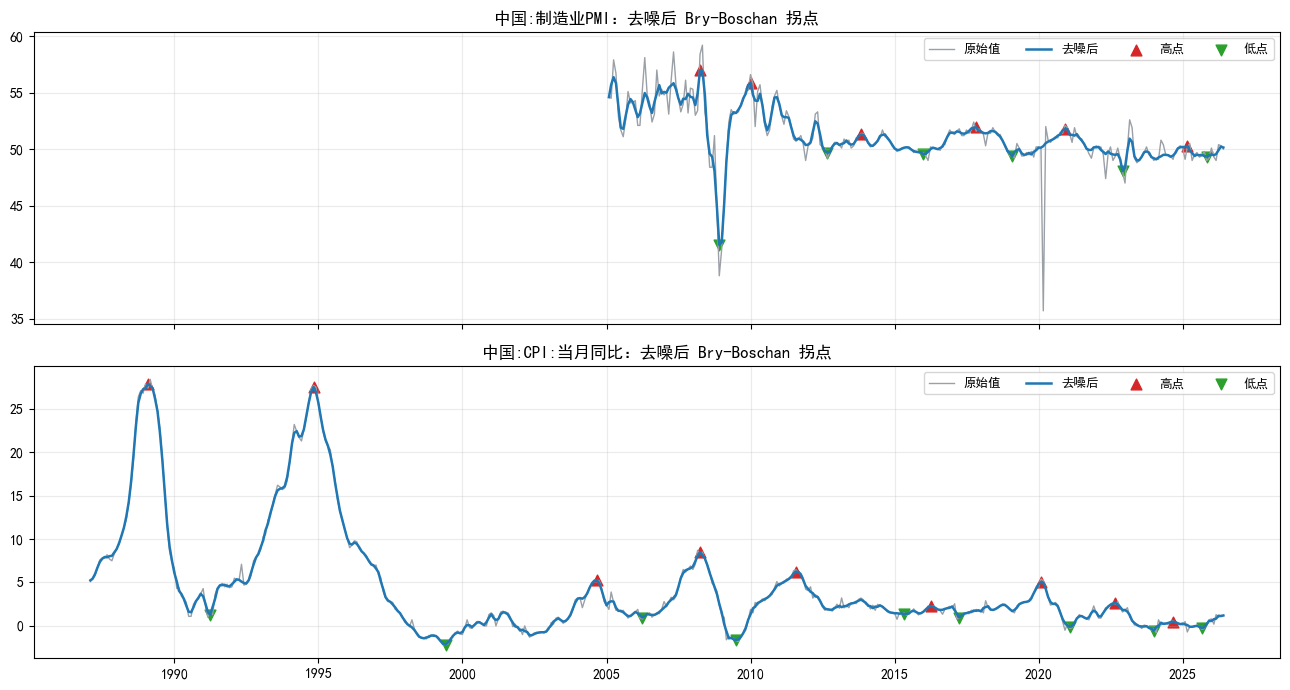

In [9]:
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, factor in zip(axes, ["growth", "inflation"]):
    raw = raw_series[factor]
    denoised = denoised_series[factor]
    turns = denoised_turning_points[denoised_turning_points["factor"].eq(factor)]
    peaks = turns[turns["type"].eq("peak")]
    troughs = turns[turns["type"].eq("trough")]

    ax.plot(raw.index, raw.values, linewidth=1.0, color="#9aa0a6", label="原始值")
    ax.plot(denoised.index, denoised.values, linewidth=1.8, color="#1f77b4", label="去噪后")
    ax.scatter(peaks["date"], peaks["value"], color="#d62728", marker="^", s=60, label="高点")
    ax.scatter(troughs["date"], troughs["value"], color="#2ca02c", marker="v", s=60, label="低点")
    ax.set_title(f"{SERIES[factor]['name']}：去噪后 Bry-Boschan 拐点")
    ax.grid(alpha=0.25)
    ax.legend(ncol=4, fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "macro_denoised_bry_boschan_turns.png", dpi=160)
plt.show()